Veneziano Milestone 5

In [114]:
import sqlite3

# connect to the SQLite database
conn = sqlite3.connect('life_expectancy.db')
print("Database connection established.")


Database connection established.


In [115]:
import pandas as pd

# load first dataset in DataFrame
df1 = pd.read_csv('life_expectancy_cleaned_v1.csv')

# save it as a table in the database
df1.to_sql('life_expectancy_cleaned', conn, if_exists='replace', index=False)
print("Table 'life_expectancy_cleaned' loaded into database.")

Table 'life_expectancy_cleaned' loaded into database.


In [116]:
# load second dataset
df2 = pd.read_csv('final_combined_life_expectancy_data_v2.csv')

# save it as a table in the database
df2.to_sql('final_combined_life_expectancy', conn, if_exists='replace', index=False)
print("Table 'final_combined_life_expectancy' loaded into the database.")

Table 'final_combined_life_expectancy' loaded into the database.


In [117]:
# load third dataset
df3 = pd.read_csv('final_transformed_life_expectancy_v3.csv')

# save it as a table in the database
df3.to_sql('final_transformed_life_expectancy', conn, if_exists='replace', index=False)
print("Table 'final_transformed_life_expectancy' loaded into the database.")

Table 'final_transformed_life_expectancy' loaded into the database.


In [118]:
# confirm the tables are loaded
print("Tables in the database:")
for table in conn.execute("SELECT name FROM sqlite_master WHERE type='table';"):
    print(table[0])

Tables in the database:
life_expectancy_cleaned
final_combined_life_expectancy
final_transformed_life_expectancy


In [119]:
# close the existing connection 
conn.close()

In [120]:
# reconnect to the SQLite database
conn = sqlite3.connect('life_expectancy.db')
cursor = conn.cursor()


In [121]:
query = """
SELECT 
    a."Country", a."Year", a."Life expectancy", a."Status", a."Adult Mortality", 
    a."infant deaths", a."Alcohol", a."percentage expenditure", a."Measles", a."BMI", 
    a."under-five deaths", a."Polio", a."Diphtheria", a."HIV/AIDS", a."thinness  1-19 years",
    a."thinness 5-9 years", a."Income composition of resources", a."Schooling", 
    b."Life Expectancy Both Sexes at Birth", b."Male Life Expectancy at Birth", 
    b."Female Life Expectancy at Birth", c."Life_Expectancy", c."Z_Score"
FROM life_expectancy_cleaned a
JOIN final_combined_life_expectancy b 
    ON a."Country" = b."Country"
JOIN final_transformed_life_expectancy c 
    ON a."Country" = c."Country" AND a."Year" = c."Year";
"""

# run the query and load the result into a DataFrame
df_combined = pd.read_sql_query(query, conn)

# preview the combined dataset
print(df_combined.head())


       Country  Year  Life expectancy      Status  Adult Mortality  \
0  Afghanistan  2015             65.0  Developing            263.0   
1  Afghanistan  2015             65.0  Developing            263.0   
2  Afghanistan  2015             65.0  Developing            263.0   
3  Afghanistan  2015             65.0  Developing            263.0   
4  Afghanistan  2015             65.0  Developing            263.0   

   infant deaths  Alcohol  percentage expenditure  Measles   BMI  ...  \
0             62     0.01               71.279624   1154.0  19.1  ...   
1             62     0.01               71.279624   1154.0  19.1  ...   
2             62     0.01               71.279624   1154.0  19.1  ...   
3             62     0.01               71.279624   1154.0  19.1  ...   
4             62     0.01               71.279624   1154.0  19.1  ...   

   HIV/AIDS  thinness  1-19 years  thinness 5-9 years  \
0       0.1                  17.2                17.3   
1       0.1               

In [122]:
# remove duplicates based on 'Country' and 'Year' columns to keep only one entry per country-year combination
df_combined = df_combined.drop_duplicates(subset=['Country', 'Year'])

# print the dataset after I removed the duplicates
print(df_combined.head())


         Country  Year  Life expectancy      Status  Adult Mortality  \
0    Afghanistan  2015             65.0  Developing            263.0   
57   Afghanistan  2014             59.9  Developing            271.0   
114  Afghanistan  2013             59.9  Developing            268.0   
171  Afghanistan  2012             59.5  Developing            272.0   
228  Afghanistan  2011             59.2  Developing            275.0   

     infant deaths  Alcohol  percentage expenditure  Measles   BMI  ...  \
0               62     0.01               71.279624   1154.0  19.1  ...   
57              64     0.01               73.523582    492.0  18.6  ...   
114             66     0.01               73.219243    430.0  18.1  ...   
171             69     0.01               78.184215   2787.0  17.6  ...   
228             71     0.01                7.097109   3013.0  17.2  ...   

     HIV/AIDS  thinness  1-19 years  thinness 5-9 years  \
0         0.1                  17.2                17.3  

In [123]:
df_combined.to_csv('cleaned_life_expectancy_combined.csv', index=False)


Visualization 1: Life Expectancy Over Time (2003-2023) for Afghanistan, India, United States, Japan and Brazil

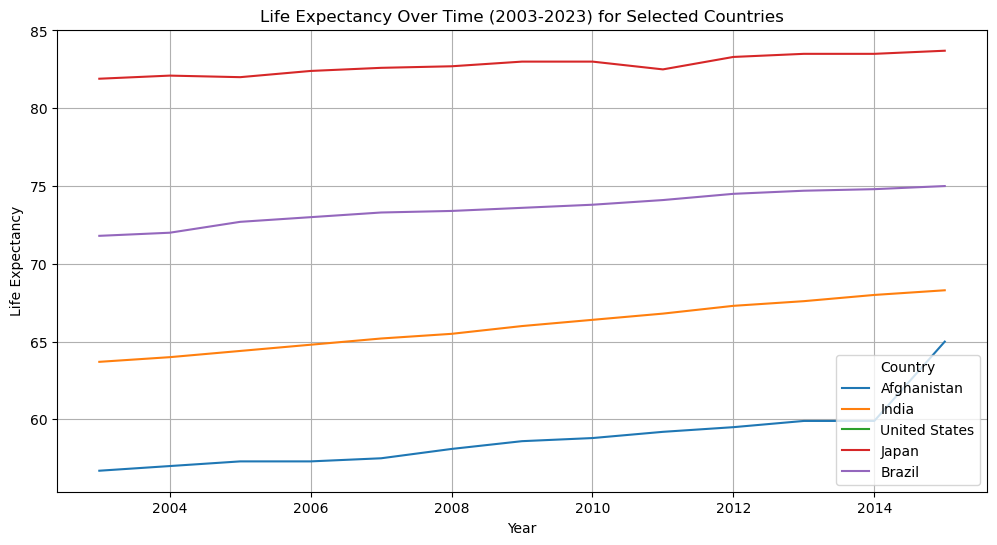

In [125]:
import matplotlib.pyplot as plt

# filter the combined dataframe for the selected countries
selected_countries = ['Afghanistan', 'India', 'United States', 'Japan', 'Brazil']
df_filtered = df_combined[df_combined['Country'].isin(selected_countries)]

# plot the life expectancy over time for each country 
plt.figure(figsize=(12, 6))

for country in selected_countries:
    country_data = df_filtered[df_filtered['Country'] == country]
    plt.plot(country_data['Year'], country_data['Life expectancy'], label=country)

plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy Over Time (2003-2023) for Selected Countries')
plt.legend(title='Country')
plt.grid(True)
plt.show()



Visualization 2: Life Expectancy vs. Immunization Rates (Polio and Diphtheria)

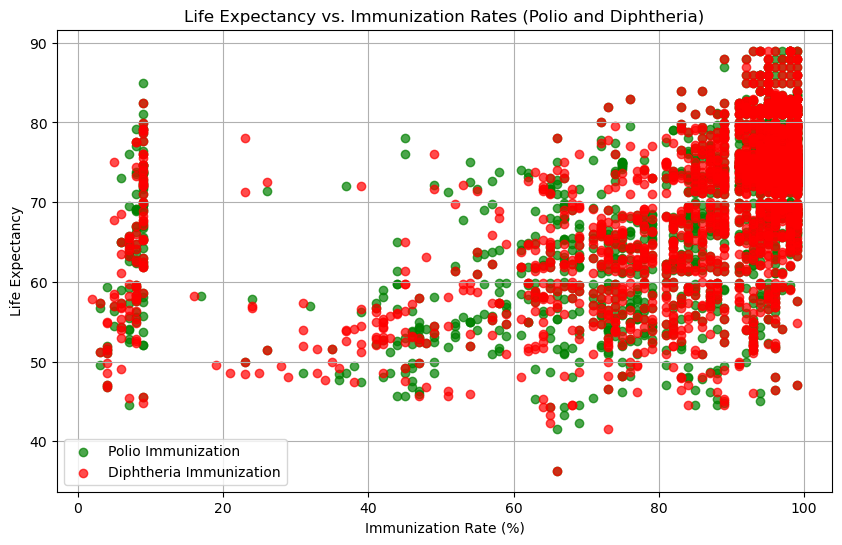

In [127]:
# scatter plot for Life Expectancy vs Immunization rates
plt.figure(figsize=(10, 6))
plt.scatter(df_combined['Polio'], df_combined['Life expectancy'], alpha=0.7, label='Polio Immunization', color='g')
plt.scatter(df_combined['Diphtheria'], df_combined['Life expectancy'], alpha=0.7, label='Diphtheria Immunization', color='r')
plt.title('Life Expectancy vs. Immunization Rates (Polio and Diphtheria)')
plt.xlabel('Immunization Rate (%)')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.show()

Visualization 3: Life Expectancy vs Schooling (2003-2023)

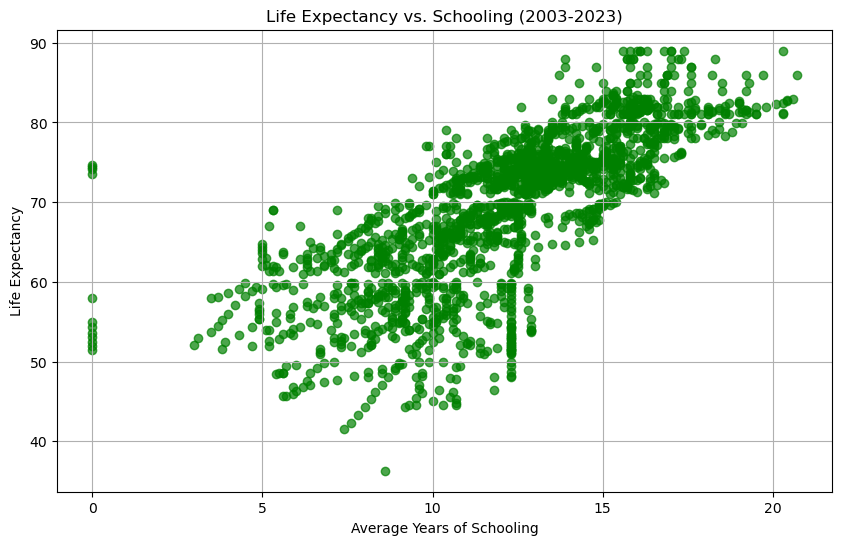

In [129]:
# scatter plot for Life Expectancy vs Schooling
plt.figure(figsize=(10, 6))
plt.scatter(df_combined['Schooling'], df_combined['Life expectancy'], alpha=0.7, color='green')
plt.title('Life Expectancy vs. Schooling (2003-2023)')
plt.xlabel('Average Years of Schooling')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.show()

Visualization 4: Average Life Expectancy Over Time by Country Status

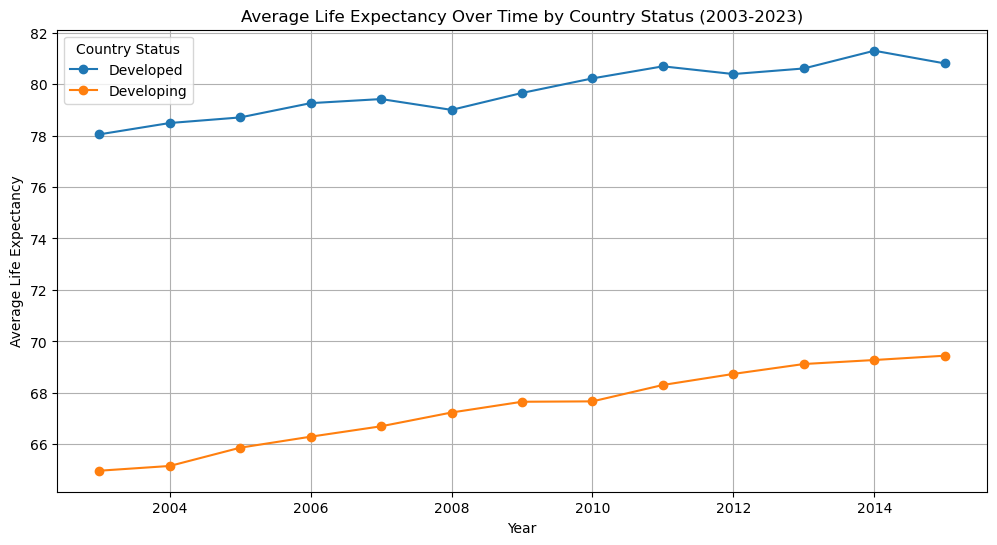

In [131]:
# line chart for average Life expectancy over time by Country Status

# group data by Status and Year, then calculate average life expectancy
df_grouped_status = df_combined.groupby(['Status', 'Year'])['Life expectancy'].mean().reset_index()

# define the statuses to visualize
statuses = df_grouped_status['Status'].unique()

# plot the average life expectancy over time for each status group
plt.figure(figsize=(12, 6))
for status in statuses:
    status_data = df_grouped_status[df_grouped_status['Status'] == status]
    plt.plot(status_data['Year'], status_data['Life expectancy'], marker='o', label=status)

plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.title('Average Life Expectancy Over Time by Country Status (2003-2023)')
plt.legend(title='Country Status')
plt.grid(True)
plt.show()


Visualization 5: Impact of Alcohol Consumption on Life Expectancy 

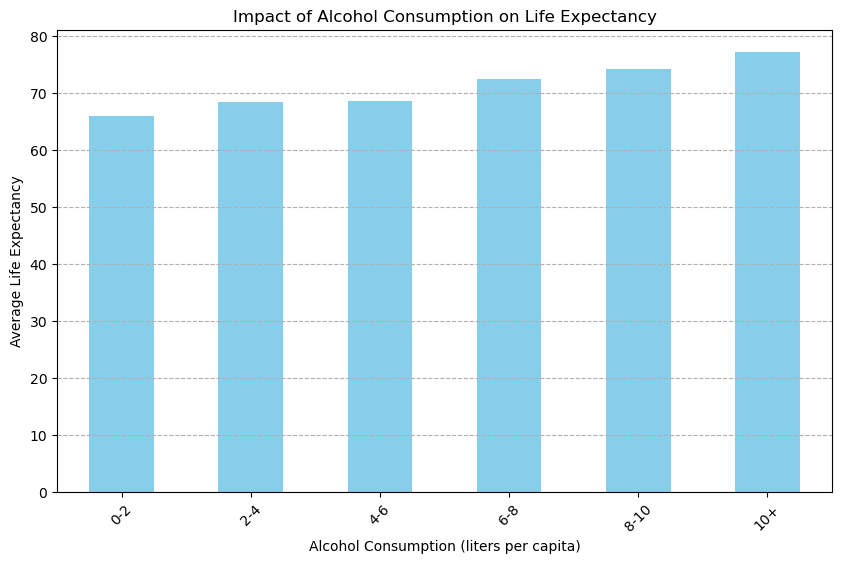

In [133]:
# bar chart on impact of alcohol consumption
# bin the alcohol consumption values into categories
bins = [0, 2, 4, 6, 8, 10, df_combined['Alcohol'].max()]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10', '10+']
df_combined['Alcohol_Bins'] = pd.cut(df_combined['Alcohol'], bins=bins, labels=labels)

# calculate the average life expectancy for each alcohol consumption category
alcohol_life_expectancy = df_combined.groupby('Alcohol_Bins', observed=False)['Life expectancy'].mean()

# plot the bar chart
plt.figure(figsize=(10, 6))
alcohol_life_expectancy.plot(kind='bar', color='skyblue')
plt.title('Impact of Alcohol Consumption on Life Expectancy')
plt.xlabel('Alcohol Consumption (liters per capita)')
plt.ylabel('Average Life Expectancy')
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.show()


In [134]:
# print human readable dataset
print(df_combined.head())

         Country  Year  Life expectancy      Status  Adult Mortality  \
0    Afghanistan  2015             65.0  Developing            263.0   
57   Afghanistan  2014             59.9  Developing            271.0   
114  Afghanistan  2013             59.9  Developing            268.0   
171  Afghanistan  2012             59.5  Developing            272.0   
228  Afghanistan  2011             59.2  Developing            275.0   

     infant deaths  Alcohol  percentage expenditure  Measles   BMI  ...  \
0               62     0.01               71.279624   1154.0  19.1  ...   
57              64     0.01               73.523582    492.0  18.6  ...   
114             66     0.01               73.219243    430.0  18.1  ...   
171             69     0.01               78.184215   2787.0  17.6  ...   
228             71     0.01                7.097109   3013.0  17.2  ...   

     thinness  1-19 years  thinness 5-9 years  \
0                    17.2                17.3   
57                

This project explores the relationship between life expectancy, mortality rates, and immunization rates across countries over the period of 2003-2023. The analysis uses data from three different sources: a flat file, a website, and an API. The data sources include a dataset from Kaggle, Wikipedia data, and data from the WHO Global Health Observatory API. The aim is to investigate how health-related factors impact life expectancy across countries during this 20-year period.

The Kaggle dataset contains life expectancy and other health-related factors such as mortality rates, immunization rates, and economic and social factors for 193 countries from 2003 to 2015. This dataset was collected from WHO and the United Nations. The Wikipedia data provides life expectancy figures by country, broken down by gender, and includes the most recent figures reported by the World Bank for 2022. This data also includes non-sovereign entities and territories. The WHO API provides access to life expectancy and other health indicators by country, covering the years 2016 to 2023.

The Kaggle dataset provides historical life expectancy data and related health indicators from 2003 to 2015. The Wikipedia life expectancy data adds the most recent figures from 2022, helping to fill the gap from 2016 to 2023. The WHO API provides real-time life expectancy data for the period from 2016 to 2023, complementing the flat file and scraped data to cover the full range of 2003-2023. The common field across all three datasets is the country name, allowing the datasets to be merged and analyzed together. The combination of these sources provides a complete view of life expectancy trends from 2003 to 2023.

I began the project by cleaning and preprocessing the Kaggle dataset to standardize country names and address missing data. Afterward, I cleaned and merged the Wikipedia life expectancy data to compare historical and recent trends. I then used the WHO API data to update the dataset from 2016 to 2023, ensuring a complete 20-year period. After merging all three datasets, I focused on visualizing key trends in life expectancy. I used various visualizations, such as scatter plots and bar charts, to explore how factors like mortality rates, immunization rates, and other available health factors impact life expectancy. I also conducted regression analysis to quantify the relationships between these factors and life expectancy across different countries.

From the visualizations, I learned several key insights. The first visualization showed the trends in life expectancy for selected countries over the period of 2003-2023, highlighting differences in life expectancy between developed and developing countries. The second visualization explored the relationship between immunization rates (Polio and Diphtheria) and life expectancy, revealing that higher immunization rates generally correlated with increased life expectancy. In the third visualization, I examined the impact of schooling on life expectancy, which showed a positive correlation—countries with higher average years of schooling tended to have higher life expectancy. The fourth visualization compared average life expectancy over time based on country status (developed vs. developing), emphasizing the consistent gap between the two groups, with developed countries having significantly higher life expectancy. Finally, the fifth visualization analyzed the impact of alcohol consumption on life expectancy, but the results were inconclusive, showing minimal differences across alcohol consumption levels. Overall, these visualizations provided a deeper understanding of how various factors contribute to life expectancy across different regions.

Some challenges included standardizing country names across the datasets, handling missing data in the Kaggle file, and ensuring consistency across the different sources. Integrating the API data from 2016 to 2023 required validating its compatibility with the structure of the flat file and scraped data. It is important to be careful when drawing conclusions about life expectancy, especially when comparing countries with very different levels of wealth and healthcare. The data should be looked at thoughtfully to avoid simplifying the many factors that affect life expectancy, such as access to healthcare, social inequality, and changes over time.

The data used in this project was acquired ethically, as it came from openly accessible and credible sources: Kaggle, Wikipedia, and the WHO Global Health Observatory API. These sources are known for providing reliable data, and I ensured that the data was used responsibly. I also gave careful consideration to the differences in wealth, healthcare access, and social conditions across countries to avoid oversimplifying the complex factors impacting life expectancy.
